In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# Set viridis sebagai colormap default
mpl.rcParams['image.cmap'] = 'viridis'

# Untuk grafik seaborn
sns.set_theme(style="whitegrid", palette="viridis")
# =========================
# LOAD DATA
# =========================

file_path = '/content/Study Case for Univ Airlangga 2026 _Actuarial AXA (Sent 2026.05.26).xlsx'

df_prem = pd.read_excel(file_path, sheet_name='Raw Premium')
df_claim = pd.read_excel(file_path, sheet_name='Raw Claim')

In [ ]:
# =========================
# DATA UNDERSTANDING
# =========================

print("PREMIUM SHAPE :", df_prem.shape)
print("CLAIM SHAPE   :", df_claim.shape)

print("\n=== MISSING VALUES PREMIUM ===")
print(df_prem.isnull().sum())

print("\n=== MISSING VALUES CLAIM ===")
print(df_claim.isnull().sum())

# =========================
# DATE CONVERSION
# =========================

date_cols_prem = ['DT_INC', 'DT_END']
date_cols_claim = ['DT_CLM']

for col in date_cols_prem:
    df_prem[col] = pd.to_datetime(
        df_prem[col],
        errors='coerce')

for col in date_cols_claim:
    df_claim[col] = pd.to_datetime(
        df_claim[col],
        errors='coerce')

# =========================
# UNDERWRITING YEAR
# =========================

df_prem['UW_YEAR'] = df_prem['DT_INC'].dt.year
df_claim['CLM_YEAR'] = df_claim['DT_CLM'].dt.year

# =========================
# TENURE POLICY
# =========================

df_prem['TENURE_DAYS'] = (df_prem['DT_END'] - df_prem['DT_INC']).dt.days

# =========================
# EXACT DUPLICATES
# =========================

print("\nEXACT DUPLICATE PREMIUM :", df_prem.duplicated().sum())
print("EXACT DUPLICATE CLAIM   :", df_claim.duplicated().sum())

# =========================
# NEGATIVE VALUES CHECK
# =========================

premium_cols = [
    'GWP_IDR',
    'RWP_IDR',
    'GWC_IDR',
    'RWC_IDR',
    'SUM_INSURED']

claim_cols = [
    'GRS_ST_IDR',
    'RI_ST_IDR',
    'GRS_OS_IDR',
    'RI_OS_IDR']

print("\n=== NEGATIVE VALUES PREMIUM ===")
for col in premium_cols:
    print(col, (df_prem[col] < 0).sum())

print("\n=== NEGATIVE VALUES CLAIM ===")
for col in claim_cols:
    print(col, (df_claim[col] < 0).sum())

# =========================
# UNIQUE SEGMENTS
# =========================

segment_cols = [
    'COB',
    'BRANCH_',
    'CHANNEL_',
    'PRODUCT_NAME']

print("\n=== UNIQUE SEGMENTS ===")
for col in segment_cols:
    print(f"\n{col}")
    print(df_prem[col].nunique())

# =========================
# BASIC STATISTICS
# =========================

print("\n=== PREMIUM STATISTICS ===")

print(
    df_prem[
        premium_cols
    ].describe())

print("\n=== CLAIM STATISTICS ===")

print(
    df_claim[
        claim_cols
    ].describe())

# =========================
# TENURE DISTRIBUTION
# =========================

print("\n=== TENURE SUMMARY ===")
print(df_prem['TENURE_DAYS'].describe())

PREMIUM SHAPE : (390124, 12)
CLAIM SHAPE   : (20087, 10)

=== MISSING VALUES PREMIUM ===
COB             0
BRANCH_         0
CHANNEL_        0
PRODUCT_NAME    0
POLICY_NO       0
DT_INC          0
DT_END          0
GWP_IDR         0
RWP_IDR         0
GWC_IDR         0
RWC_IDR         0
SUM_INSURED     0
dtype: int64

=== MISSING VALUES CLAIM ===
COB           0
BRANCH_       0
CHANNEL_      0
POLICY_NO     0
CLM_REF       0
DT_CLM        0
GRS_ST_IDR    0
RI_ST_IDR     0
GRS_OS_IDR    0
RI_OS_IDR     0
dtype: int64

EXACT DUPLICATE PREMIUM : 0
EXACT DUPLICATE CLAIM   : 0

=== NEGATIVE VALUES PREMIUM ===
GWP_IDR 0
RWP_IDR 71
GWC_IDR 14
RWC_IDR 252
SUM_INSURED 0

=== NEGATIVE VALUES CLAIM ===
GRS_ST_IDR 1
RI_ST_IDR 0
GRS_OS_IDR 0
RI_OS_IDR 0

=== UNIQUE SEGMENTS ===

COB
10

BRANCH_
10

CHANNEL_
5

PRODUCT_NAME
97

=== PREMIUM STATISTICS ===
            GWP_IDR       RWP_IDR       GWC_IDR       RWC_IDR   SUM_INSURED
count  3.901240e+05  3.901240e+05  3.901240e+05  3.901240e+05  3.901240e



> Dataset premium terdiri dari 390.214 polis dan dataset klaim terdiri dari 20.087 klaim. Dari pemeriksaan kualitas data, tidak ada missing value maupun data duplikat yang ditemukan dalam dataset.



> Ditemukan sejumlah kecil nilai negatif pada beberapa variabel premi dan klaim dengan proporsi sangat kecil, sehingga kemungkinan besar dari proses penyesuaian transaksi, pembatalan polis, atau koreksi pencatatan.

> 10 kategori COB, 10 Branch, 5 Channel, dan 97 Produk menunjukkan bahwa portofolio tidak terkonsentrasi pada satu jenis bisnis sehingga analisis profitabilitas dan risiko sebaiknya dilakukan pada tingkat segmen untuk mengidentifikasi segmen yang memberikan kontribusi kinerja terbaik maupun terburuk

> Distribusi premi, nilai pertanggungan, dan klaim menunjukkan pola yang sangat tidak merata, di mana sebagian besar polis dan klaim bernilai relatif kecil, tetapi terdapat sejumlah kecil polis dan klaim bernilai sangat besar yang mendominasi portofolio. Kondisi ini mengindikasikan adanya risiko konsentrasi yang perlu mendapat perhatian khusus karena dapat memberikan dampak besar terhadap kinerja perusahaan apabila terjadi kerugian pada eksposur bernilai tinggi.

> Selain itu, proporsi premi reasuransi menunjukkan bahwa perusahaan masih mempertahankan sebagian besar risiko pada portofolionya sendiri, sementara reasuransi digunakan untuk mengelola eksposur yang lebih besar. Dari sisi durasi polis, rata-rata tenure sekitar 2,7 tahun menunjukkan adanya basis nasabah yang relatif stabil dan tingkat retensi yang cukup baik. Secara keseluruhan, portofolio memiliki kualitas data yang baik, diversifikasi bisnis yang cukup luas, namun tetap perlu memperhatikan risiko konsentrasi pada polis dan klaim bernilai besar.




**Portfolio Overview**


Overall Totals

In [ ]:
total_gwp = df_prem['GWP_IDR'].sum()
total_rwp = df_prem['RWP_IDR'].sum()
total_gwc = df_prem['GWC_IDR'].sum()
total_sum_insured = df_prem['SUM_INSURED'].sum()
total_unique_policies = df_prem['POLICY_NO'].nunique()

print(f"Total GWP: {total_gwp:,.2f} IDR")
print(f"Total RWP: {total_rwp:,.2f} IDR")
print(f"Total GWC: {total_gwc:,.2f} IDR")
print(f"Total Sum Insured: {total_sum_insured:,.2f} IDR")
print(f"Total Unique Policies: {total_unique_policies:,}")

Total GWP: 2,510,719,474,050.44 IDR
Total RWP: 546,598,216,481.78 IDR
Total GWC: 559,798,314,685.83 IDR
Total Sum Insured: 2,986,545,443,874,958.00 IDR
Total Unique Policies: 156,301




> Portofolio yang dianalisis terdiri dari 156.301 polis unik dengan total Gross Written Premium (GWP) sebesar Rp2,51 triliun. Dari total premi tersebut, perusahaan mengalihkan sekitar Rp546,60 miliar kepada reasuradur atau setara dengan 21,8% dari total GWP, yang menunjukkan bahwa sebagian besar risiko masih dipertahankan dalam portofolio perusahaan. Di sisi lain, total Gross Written Commission (GWC) mencapai Rp559,80 miliar atau sekitar 22,3% dari total premi, mengindikasikan bahwa biaya distribusi dan akuisisi memiliki kontribusi yang cukup signifikan terhadap struktur biaya bisnis.

> Total Sum Insured mencapai Rp2.986,5 triliun, mencerminkan besarnya eksposur risiko yang dikelola perusahaan dibandingkan dengan premi yang diperoleh. Temuan ini menunjukkan bahwa meskipun portofolio menghasilkan premi yang kuat, terdapat eksposur risiko yang sangat besar sehingga efektivitas pengelolaan risiko, strategi underwriting, dan program reasuransi menjadi faktor penting dalam menjaga profitabilitas dan ketahanan portofolio secara keseluruhan.



Analisis GWP

                Metric                 Value
0  Total Gross Premium     2,510,719,474,050
1    Total Net Premium     1,964,121,257,569
2    Total Sum Insured 2,986,545,443,874,958
3       Total Policies               156,301

===== SUMMARY BY COB =====
              GWP_IDR     NET_PREMIUM           SUM_INSURED  POLICY_NO
COB                                                                   
COB 9 762,410,875,051 466,992,006,665   736,562,866,601,112      46754
COB 6 420,660,523,861 415,183,610,360 1,354,778,000,175,338       4876
COB 7 342,980,363,837 342,696,880,968    21,284,400,161,162      41763
COB 4 319,207,543,543 262,999,721,742   555,915,663,410,280       1693
COB 8 251,534,301,544 251,489,475,694    71,855,812,949,910       2382


/tmp/ipykernel_9224/2182700108.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary.reset_index(),


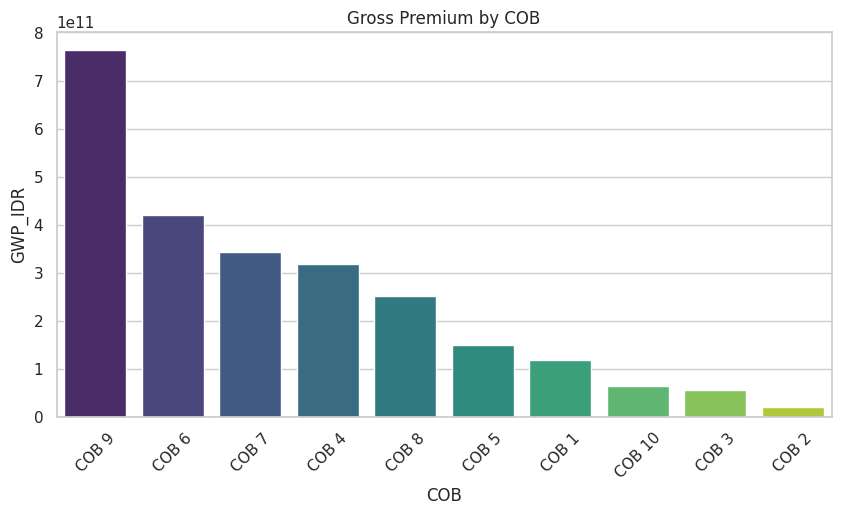


===== SUMMARY BY BRANCH_ =====
                   GWP_IDR     NET_PREMIUM           SUM_INSURED  POLICY_NO
BRANCH_                                                                    
BRANCH K 1,176,841,188,632 841,560,790,407 1,031,902,980,572,525      46405
BRANCH J   414,638,800,959 319,866,357,568 1,447,252,432,030,847      45817
BRANCH D   159,261,904,998 109,877,907,725    96,460,304,531,245      12709
BRANCH E   154,220,879,678 136,752,085,173   101,024,164,988,012      10557
BRANCH A   151,824,760,103 132,183,192,700    84,085,344,267,895      10566


/tmp/ipykernel_9224/2182700108.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary.reset_index(),


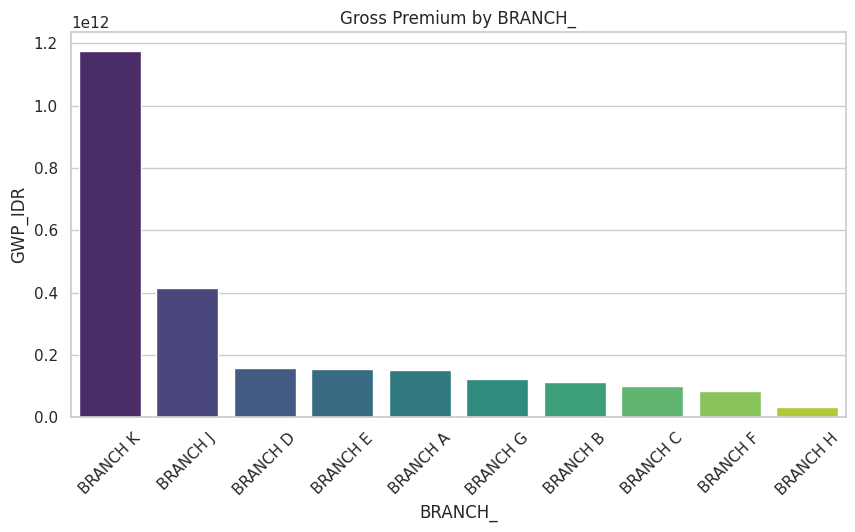


===== SUMMARY BY CHANNEL_ =====
                  GWP_IDR     NET_PREMIUM           SUM_INSURED  POLICY_NO
CHANNEL_                                                                  
CHANNEL D 757,671,016,129 712,137,774,297   420,261,013,276,463      61230
CHANNEL C 701,022,198,505 369,611,842,936   933,538,880,453,687       9303
CHANNEL B 488,183,311,310 483,613,840,521   125,301,505,460,428      37073
CHANNEL E 327,136,065,738 191,488,942,822 1,319,732,095,340,124       6453
CHANNEL A 236,706,882,369 207,268,856,993   187,711,949,344,258      42251


/tmp/ipykernel_9224/2182700108.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary.reset_index(),


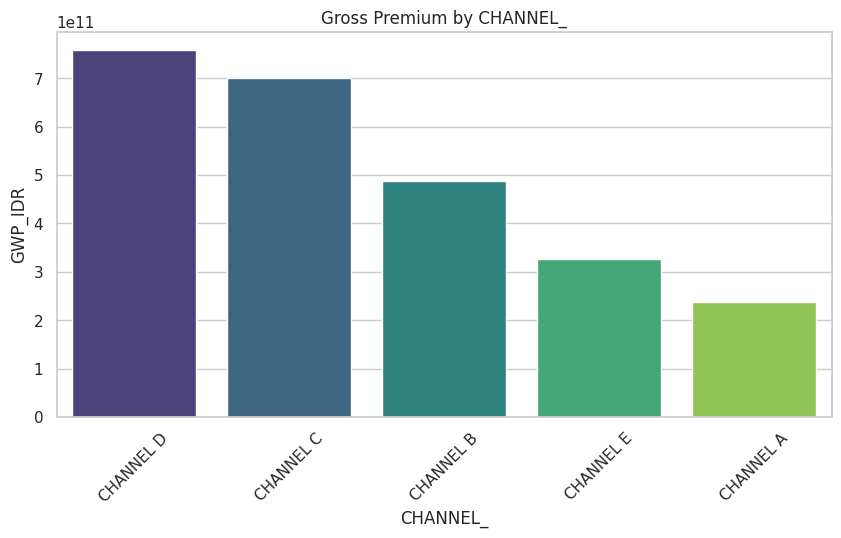

In [ ]:
# =========================
# STEP 2 - PORTFOLIO OVERVIEW
# =========================
import pandas as pd

pd.options.display.float_format = '{:,.0f}'.format
# Net Premium
df_prem['NET_PREMIUM'] = (df_prem['GWP_IDR'] - df_prem['RWP_IDR'])

# Portfolio Summary
portfolio_summary = pd.DataFrame({
    'Metric': [
        'Total Gross Premium',
        'Total Net Premium',
        'Total Sum Insured',
        'Total Policies'],
    'Value': [
        df_prem['GWP_IDR'].sum(),
        df_prem['NET_PREMIUM'].sum(),
        df_prem['SUM_INSURED'].sum(),
        df_prem['POLICY_NO'].nunique()]})

print(portfolio_summary)

# =========================
# SEGMENT OVERVIEW
# =========================

segment_cols = ['COB', 'BRANCH_', 'CHANNEL_']

for seg in segment_cols:

    summary = (
        df_prem
        .groupby(seg)
        .agg({
            'GWP_IDR':'sum',
            'NET_PREMIUM':'sum',
            'SUM_INSURED':'sum',
            'POLICY_NO':'nunique' })
        .sort_values(by='GWP_IDR', ascending=False))

    print(f"\n===== SUMMARY BY {seg} =====")
    print(summary.head())

    # Visualization
    plt.figure(figsize=(10,5))

    sns.barplot(data=summary.reset_index(),
                x=seg,
                y='GWP_IDR',
                palette = 'viridis')

    plt.title(f'Gross Premium by {seg}')
    plt.xticks(rotation=45)
    plt.show()

> Portofolio perusahaan menghasilkan gross premium sebesar Rp2,51 triliun dan net premium sebesar Rp1,96 triliun dari 156.301 polis, dengan total sum insured mencapai Rp2.986,5 triliun. Perbedaan antara gross dan net premium menunjukkan bahwa sebagian risiko telah dialihkan melalui skema reasuransi, namun mayoritas premi masih dipertahankan sebagai retensi perusahaan.

**Berdasarkan COB**
> Kontributor premi terbesar berasal dari COB 9 dengan gross premium sebesar Rp762,4 miliar atau sekitar 30% dari total portofolio, diikuti oleh COB 6 sebesar Rp420,7 miliar dan COB 7 sebesar Rp343,0 miliar. Menariknya, COB 6 memiliki nilai sum insured terbesar yaitu Rp1.354,8 triliun, jauh melampaui COB lainnya meskipun jumlah polisnya relatif kecil. Hal ini mengindikasikan bahwa COB 6 berisi risiko-risiko bernilai tinggi yang memerlukan perhatian khusus dari sisi underwriting dan manajemen risiko. Sementara itu, COB 9 dan COB 7 menunjukkan kombinasi volume polis dan kontribusi premi yang besar sehingga menjadi penggerak utama pendapatan perusahaan.

**Berdasarkan Branch**
> Dari sisi cabang, Branch K merupakan kontributor terbesar dengan gross premium sebesar Rp1,18 triliun atau hampir setengah dari total premi portofolio. Cabang ini juga memiliki jumlah polis tertinggi sehingga menjadi pusat bisnis utama perusahaan. Branch J menempati posisi kedua dengan gross premium sebesar Rp414,6 miliar, namun memiliki total sum insured tertinggi yaitu Rp1.447,3 triliun. Temuan ini menunjukkan bahwa Branch J menangani eksposur risiko yang lebih besar dibandingkan kontribusi preminya, sehingga perlu dilakukan evaluasi lebih lanjut terkait kecukupan premi terhadap risiko yang ditanggung.

**Berdasarkan Channel**
> Dari sisi distribusi, Channel D menjadi kontributor premi terbesar dengan gross premium sebesar Rp757,7 miliar dan lebih dari 61 ribu polis, menunjukkan efektivitas channel ini dalam menghasilkan volume bisnis. Namun dari sisi eksposur risiko, Channel E memiliki total sum insured terbesar yaitu Rp1.319,7 triliun meskipun hanya berasal dari sekitar 6.400 polis. Hal ini mengindikasikan bahwa Channel E berfokus pada bisnis dengan nilai pertanggungan yang sangat besar. Sementara itu, Channel C juga menunjukkan eksposur yang tinggi dengan sum insured mencapai Rp933,5 triliun, tetapi net premium yang diterima relatif lebih rendah dibanding gross premium, yang mengindikasikan penggunaan reasuransi yang lebih intensif pada channel tersebut.


> Secara keseluruhan, portofolio menunjukkan bahwa sumber pendapatan utama perusahaan terkonsentrasi pada COB 9, Branch K, dan Channel D, sementara eksposur risiko terbesar terkonsentrasi pada COB 6, Branch J, dan Channel E. Temuan ini mengindikasikan bahwa area dengan kontribusi premi terbesar tidak selalu merupakan area dengan eksposur risiko terbesar. Oleh karena itu, evaluasi profitabilitas, loss ratio, dan efektivitas reasuransi pada segmen-segmen tersebut menjadi prioritas untuk memastikan pertumbuhan premi tetap sejalan dengan tingkat risiko yang ditanggung perusahaan.

Analisis COB

In [ ]:
cob_analysis = df_prem.groupby('COB').agg(
    Total_GWP=('GWP_IDR', 'sum'),
    Total_RWP=('RWP_IDR', 'sum'),
    Total_GWC=('GWC_IDR', 'sum'),
    Total_Sum_Insured=('SUM_INSURED', 'sum'),
    Num_Policies=('POLICY_NO', 'nunique')
).reset_index()

cob_analysis['Prop_GWP'] = (cob_analysis['Total_GWP'] / total_gwp) * 100
cob_analysis['Prop_RWP'] = (cob_analysis['Total_RWP'] / total_rwp) * 100
cob_analysis['Prop_GWC'] = (cob_analysis['Total_GWC'] / total_gwc) * 100
cob_analysis['Prop_Sum_Insured'] = (cob_analysis['Total_Sum_Insured'] / total_sum_insured) * 100
cob_analysis['Prop_Num_Policies'] = (cob_analysis['Num_Policies'] / total_unique_policies) * 100

display(cob_analysis.sort_values(by='Total_GWP', ascending=False))

,COB,Total_GWP,Total_RWP,Total_GWC,Total_Sum_Insured,Num_Policies,Prop_GWP,Prop_RWP,Prop_GWC,Prop_Sum_Insured,Prop_Num_Policies
9,COB 9,7.624109e+11,2.954189e+11,7.531973e+10,7.365629e+14,46754,30.366231,54.046804,13.454797,24.662704,29.912796
6,COB 6,4.206605e+11,5.476914e+09,1.828905e+11,1.354778e+15,4876,16.754581,1.002000,32.670777,45.362712,3.119622
7,COB 7,3.429804e+11,2.834829e+08,5.677692e+10,2.128440e+13,41763,13.660641,0.051863,10.142389,0.712676,26.719599
4,COB 4,3.192075e+11,5.620782e+10,8.315382e+10,5.559157e+14,1693,12.713788,10.283206,14.854247,18.614003,1.083166
8,COB 8,2.515343e+11,4.482585e+07,1.093846e+11,7.185581e+13,2382,10.018415,0.008201,19.539996,2.405984,1.523983
5,COB 5,1.510009e+11,7.631139e+10,1.677699e+10,2.516984e+13,909,6.014248,13.961149,2.996970,0.842775,0.581570
0,COB 1,1.196189e+11,6.993509e+10,1.775699e+10,9.131532e+13,4983,4.764328,12.794606,3.172034,3.057557,3.188079
1,COB 10,6.489250e+10,0.000000e+00,1.048032e+10,1.055785e+14,52085,2.584618,0.000000,1.872159,3.535136,33.323523
3,COB 3,5.746793e+10,4.291977e+10,2.909283e+09,2.327878e+13,835,2.288903,7.852161,0.519702,0.779455,0.534226
2,COB 2,2.094564e+10,5.180234e+04,4.349233e+09,8.063062e+11,21,0.834248,0.000009,0.776929,0.026998,0.013436


> Analisis berdasarkan COB menunjukkan karakteristik portofolio yang berbeda pada setiap segmen. COB 9 menjadi kontributor premi terbesar dengan porsi 30,4% dari total GWP, sehingga merupakan penggerak utama pendapatan perusahaan. Sementara itu, COB 6 memiliki eksposur risiko terbesar dengan kontribusi 45,4% dari total sum insured meskipun hanya menyumbang 16,8% premi, sehingga perlu menjadi fokus dalam pengelolaan risiko. Di sisi lain, COB 10 memiliki jumlah polis terbesar (33,3% dari total polis), namun hanya menghasilkan 2,6% premi, yang mengindikasikan dominasi polis bernilai kecil. Temuan ini menunjukkan bahwa segmen penyumbang premi terbesar, eksposur terbesar, dan volume bisnis terbesar berasal dari COB yang berbeda sehingga memerlukan strategi pengelolaan yang berbeda pula.

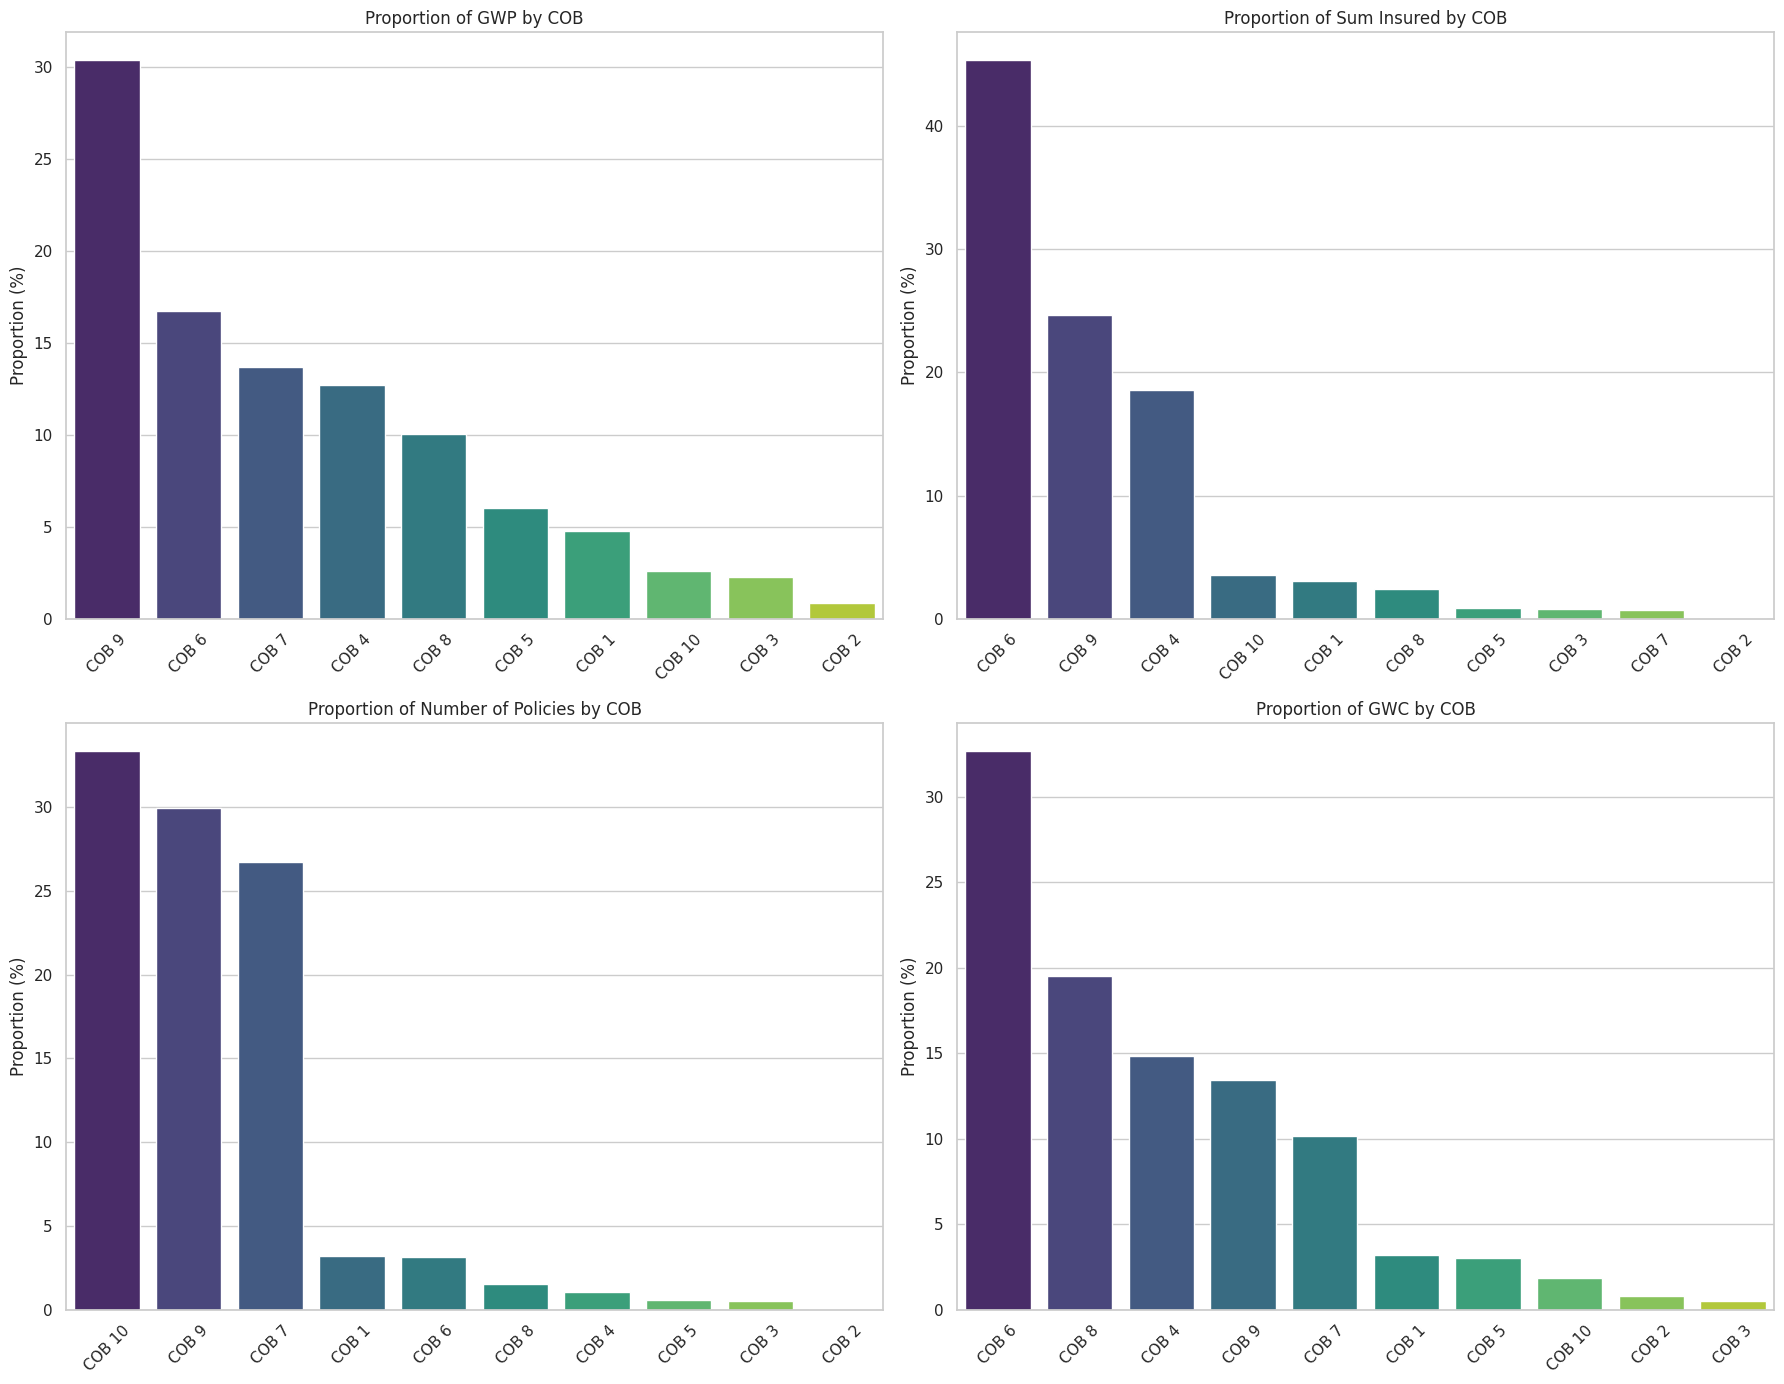

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

metrics = ['Prop_GWP', 'Prop_Sum_Insured', 'Prop_Num_Policies', 'Prop_GWC']
titles = ['Proportion of GWP by COB', 'Proportion of Sum Insured by COB', 'Proportion of Number of Policies by COB', 'Proportion of GWC by COB']

for i, metric in enumerate(metrics):
    sns.barplot(x='COB', y=metric, data=cob_analysis.sort_values(by=metric, ascending=False), ax=axes[i], palette='viridis', hue='COB', legend=False)
    axes[i].set_title(titles[i])
    axes[i].set_ylabel('Proportion (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Analisis Branch

In [ ]:
branch_analysis = df_prem.groupby('BRANCH_').agg(
    Total_GWP=('GWP_IDR', 'sum'),
    Total_RWP=('RWP_IDR', 'sum'),
    Total_GWC=('GWC_IDR', 'sum'),
    Total_Sum_Insured=('SUM_INSURED', 'sum'),
    Num_Policies=('POLICY_NO', 'nunique')
).reset_index()

branch_analysis['Prop_GWP'] = (branch_analysis['Total_GWP'] / total_gwp) * 100
branch_analysis['Prop_RWP'] = (branch_analysis['Total_RWP'] / total_rwp) * 100
branch_analysis['Prop_GWC'] = (branch_analysis['Total_GWC'] / total_gwc) * 100
branch_analysis['Prop_Sum_Insured'] = (branch_analysis['Total_Sum_Insured'] / total_sum_insured) * 100
branch_analysis['Prop_Num_Policies'] = (branch_analysis['Num_Policies'] / total_unique_policies) * 100

display(branch_analysis.sort_values(by='Total_GWP', ascending=False))

,BRANCH_,Total_GWP,Total_RWP,Total_GWC,Total_Sum_Insured,Num_Policies,Prop_GWP,Prop_RWP,Prop_GWC,Prop_Sum_Insured,Prop_Num_Policies
9,BRANCH K,1.176841e+12,3.352804e+11,2.842884e+11,1.031903e+15,46405,46.872667,61.339461,50.784071,34.551725,29.689509
8,BRANCH J,4.146388e+11,9.477244e+10,6.587894e+10,1.447252e+15,45817,16.514740,17.338594,11.768335,48.459080,29.313312
3,BRANCH D,1.592619e+11,4.938400e+10,3.534764e+10,9.646030e+13,12709,6.343278,9.034789,6.314353,3.229829,8.131106
4,BRANCH E,1.542209e+11,1.746879e+10,3.353278e+10,1.010242e+14,10557,6.142497,3.195911,5.990153,3.382643,6.754275
0,BRANCH A,1.518248e+11,1.964157e+10,3.132674e+10,8.408534e+13,10566,6.047062,3.593420,5.596075,2.815472,6.760034
6,BRANCH G,1.238995e+11,5.053118e+09,3.149790e+10,5.685779e+13,6212,4.934819,0.924467,5.626652,1.903798,3.974383
1,BRANCH B,1.135347e+11,3.523662e+09,3.245401e+10,5.013800e+13,7218,4.522000,0.644653,5.797447,1.678796,4.618013
2,BRANCH C,1.008948e+11,1.102134e+10,2.140243e+10,5.816792e+13,9626,4.018559,2.016352,3.823239,1.947666,6.158630
5,BRANCH F,8.281286e+10,6.796002e+09,1.868748e+10,3.463459e+13,5291,3.298372,1.243327,3.338252,1.159687,3.385135
7,BRANCH H,3.279013e+10,3.656890e+09,5.382024e+09,2.602192e+13,1912,1.306005,0.669027,0.961422,0.871305,1.223281


> Dari sisi cabang, Branch K merupakan kontributor utama portofolio dengan menyumbang 46,9% total premi perusahaan, 50,8% total komisi, dan 61,3% total premi reasuransi. Hal ini menunjukkan bahwa sebagian besar aktivitas bisnis dan transfer risiko perusahaan terkonsentrasi pada cabang tersebut. Sementara itu, Branch J memiliki karakteristik yang berbeda, yaitu menyumbang 48,5% total sum insured meskipun kontribusi preminya hanya 16,5%. Temuan ini mengindikasikan bahwa Branch J mengelola eksposur risiko yang sangat besar dibandingkan pendapatan premi yang dihasilkan. Secara keseluruhan, Branch K menjadi penggerak utama pendapatan perusahaan, sedangkan Branch J menjadi pusat eksposur risiko terbesar yang perlu mendapat perhatian khusus dalam pengelolaan risiko dan profitabilitas.


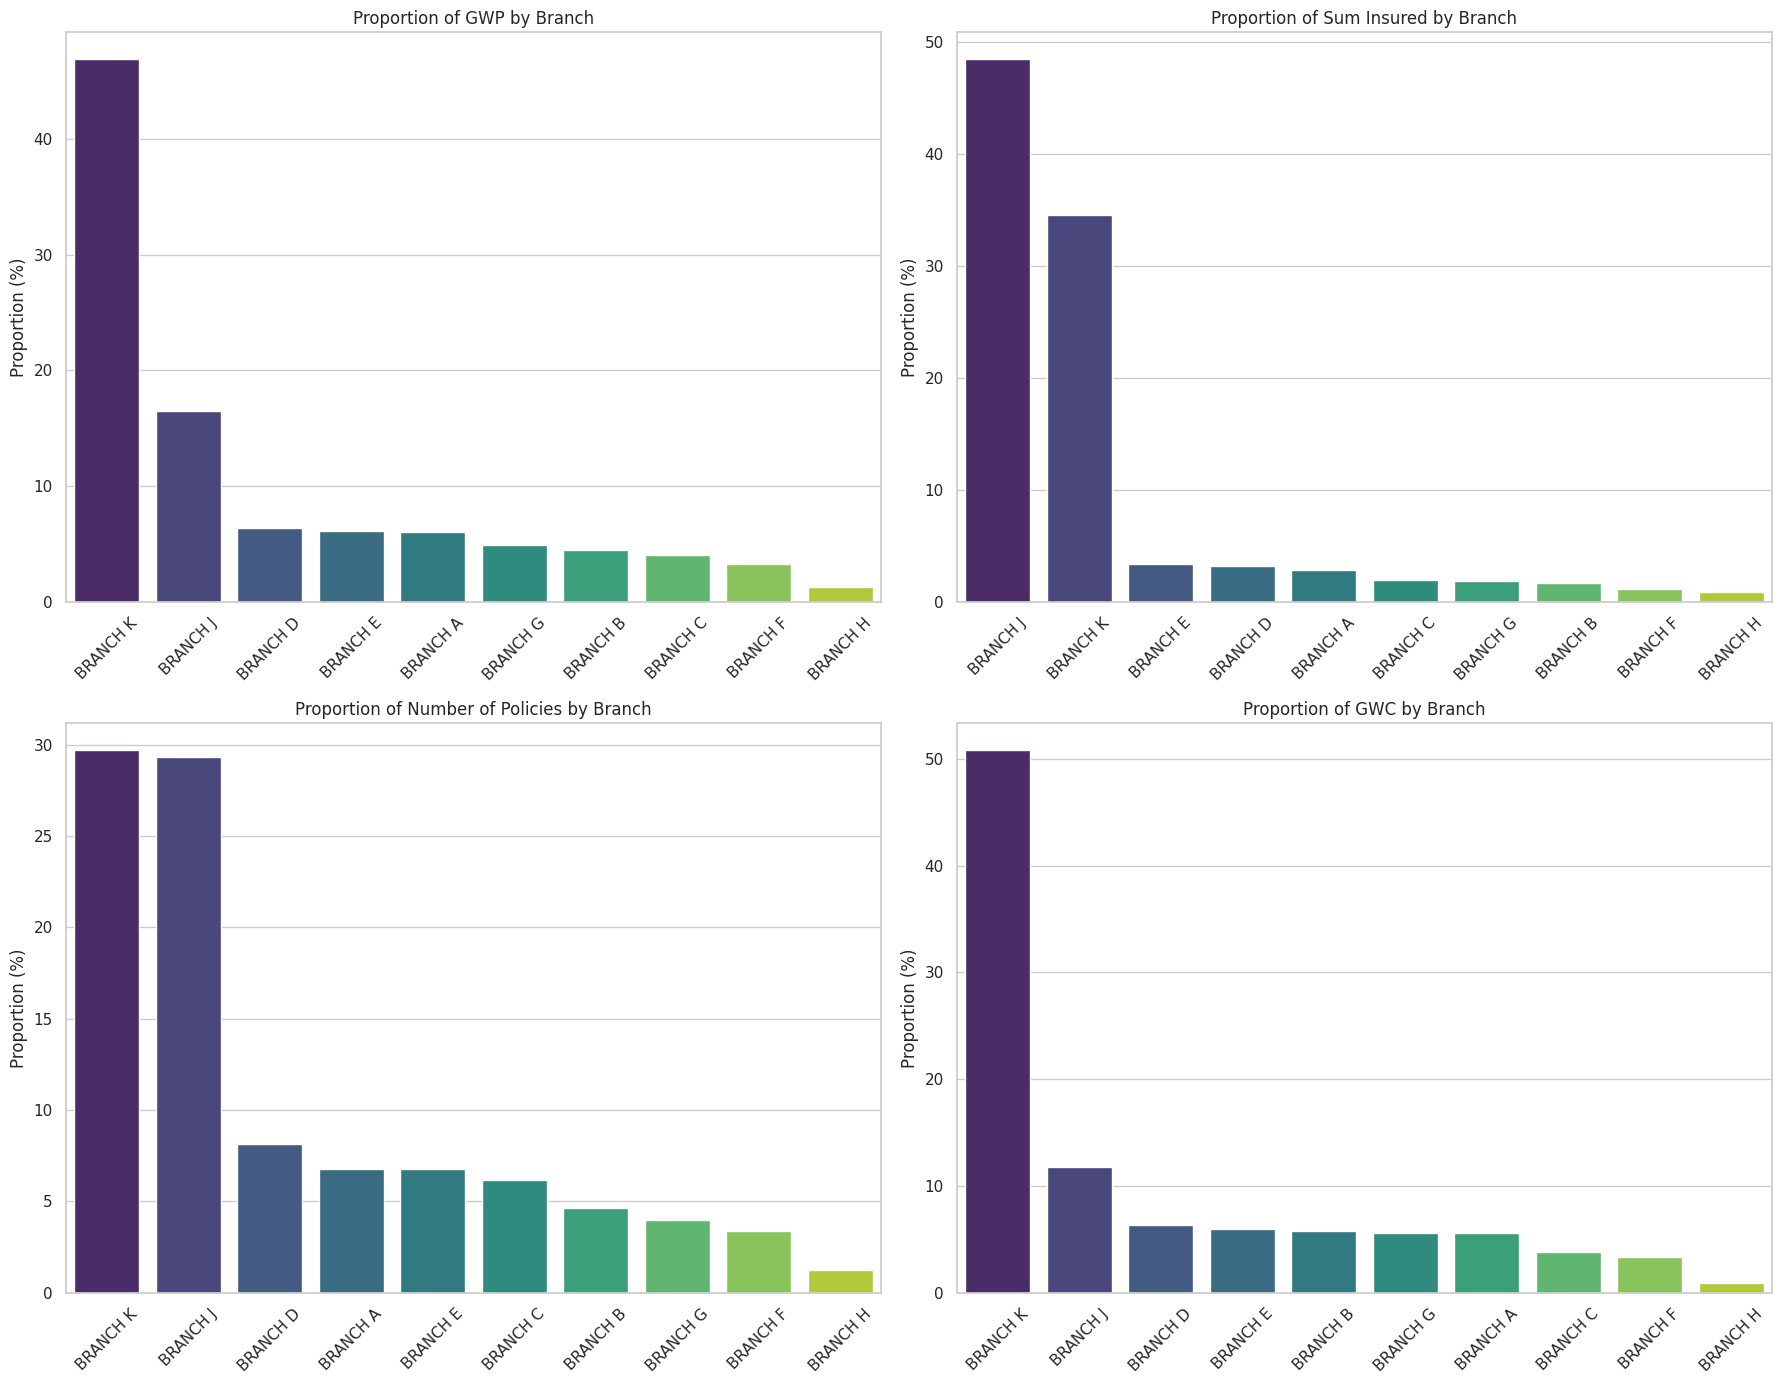

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

metrics = ['Prop_GWP', 'Prop_Sum_Insured', 'Prop_Num_Policies', 'Prop_GWC']
titles = ['Proportion of GWP by Branch', 'Proportion of Sum Insured by Branch', 'Proportion of Number of Policies by Branch', 'Proportion of GWC by Branch']

for i, metric in enumerate(metrics):
    sns.barplot(x='BRANCH_', y=metric, data=branch_analysis.sort_values(by=metric, ascending=False), ax=axes[i], palette='viridis', hue='BRANCH_', legend=False)
    axes[i].set_title(titles[i])
    axes[i].set_ylabel('Proportion (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Analisis Chanel

In [ ]:
channel_analysis = df_prem.groupby('CHANNEL_').agg(
    Total_GWP=('GWP_IDR', 'sum'),
    Total_RWP=('RWP_IDR', 'sum'),
    Total_GWC=('GWC_IDR', 'sum'),
    Total_Sum_Insured=('SUM_INSURED', 'sum'),
    Num_Policies=('POLICY_NO', 'nunique')
).reset_index()

channel_analysis['Prop_GWP'] = (channel_analysis['Total_GWP'] / total_gwp) * 100
channel_analysis['Prop_RWP'] = (channel_analysis['Total_RWP'] / total_rwp) * 100
channel_analysis['Prop_GWC'] = (channel_analysis['Total_GWC'] / total_gwc) * 100
channel_analysis['Prop_Sum_Insured'] = (channel_analysis['Total_Sum_Insured'] / total_sum_insured) * 100
channel_analysis['Prop_Num_Policies'] = (channel_analysis['Num_Policies'] / total_unique_policies) * 100

display(channel_analysis.sort_values(by='Total_GWP', ascending=False))

,CHANNEL_,Total_GWP,Total_RWP,Total_GWC,Total_Sum_Insured,Num_Policies,Prop_GWP,Prop_RWP,Prop_GWC,Prop_Sum_Insured,Prop_Num_Policies
3,CHANNEL D,7.576710e+11,4.553324e+10,1.889536e+11,4.202610e+14,61230,30.177446,8.330295,33.753862,14.071810,39.174413
2,CHANNEL C,7.010222e+11,3.314104e+11,1.016589e+11,9.335389e+14,9303,27.921168,60.631437,18.159912,31.258151,5.951977
1,CHANNEL B,4.881833e+11,4.569471e+09,1.867450e+11,1.253015e+14,37073,19.443961,0.835983,33.359336,4.195533,23.718978
4,CHANNEL E,3.271361e+11,1.356471e+11,3.030318e+10,1.319732e+15,6453,13.029575,24.816605,5.413231,44.189252,4.128572
0,CHANNEL A,2.367069e+11,2.943803e+10,5.213770e+10,1.877119e+14,42251,9.427851,5.385679,9.313658,6.285253,27.031817


> Dari sisi channel distribusi, Channel D merupakan kontributor premi terbesar dengan porsi 30,2% dari total GWP dan 39,2% dari total polis, sehingga menjadi sumber utama volume bisnis perusahaan. Sementara itu, Channel E memiliki eksposur risiko terbesar dengan kontribusi 44,2% terhadap total sum insured meskipun hanya menyumbang 13,0% premi dan 4,1% polis. Selain itu, Channel C mengalihkan sekitar 60,6% total premi reasuransi perusahaan, menunjukkan bahwa risiko yang berasal dari channel ini relatif lebih banyak ditransfer kepada reasuradur. Temuan ini menunjukkan bahwa Channel D berperan sebagai penggerak pendapatan, sedangkan Channel E dan Channel C menjadi channel yang perlu mendapat perhatian lebih dari sisi pengelolaan risiko.

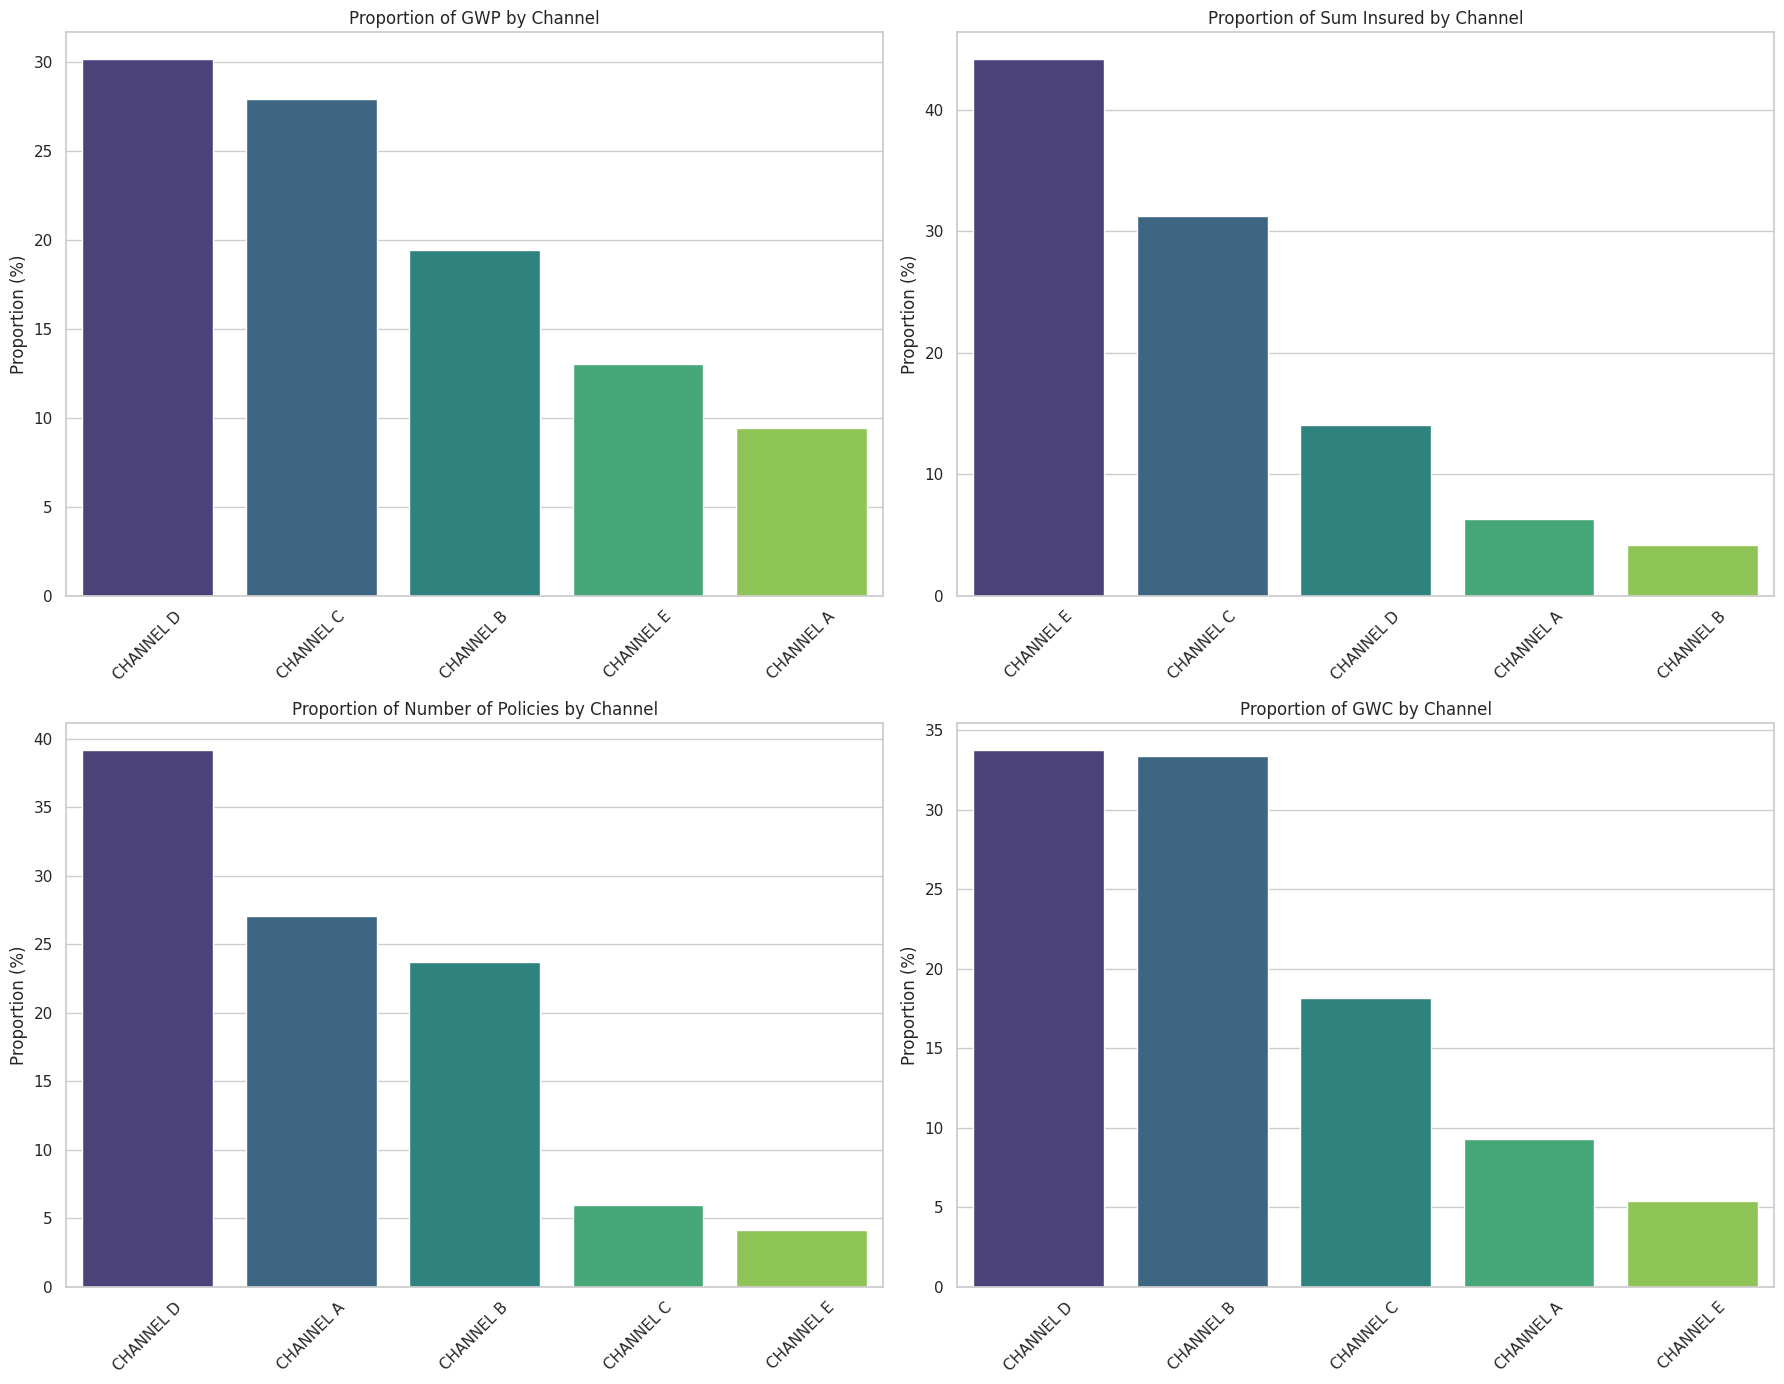

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

metrics = ['Prop_GWP', 'Prop_Sum_Insured', 'Prop_Num_Policies', 'Prop_GWC']
titles = ['Proportion of GWP by Channel', 'Proportion of Sum Insured by Channel', 'Proportion of Number of Policies by Channel', 'Proportion of GWC by Channel']

for i, metric in enumerate(metrics):
    sns.barplot(x='CHANNEL_', y=metric, data=channel_analysis.sort_values(by=metric, ascending=False), ax=axes[i], palette='viridis', hue='CHANNEL_', legend=False)
    axes[i].set_title(titles[i])
    axes[i].set_ylabel('Proportion (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()